In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

## Load Data Files

In [2]:
# for feedback provision trends
shared_hw = pd.read_csv("tables/shared_by_hw.csv")
# for template usage trends
treatment_hw = pd.read_csv("tables/treatment_by_hw.csv")

## Make Plots

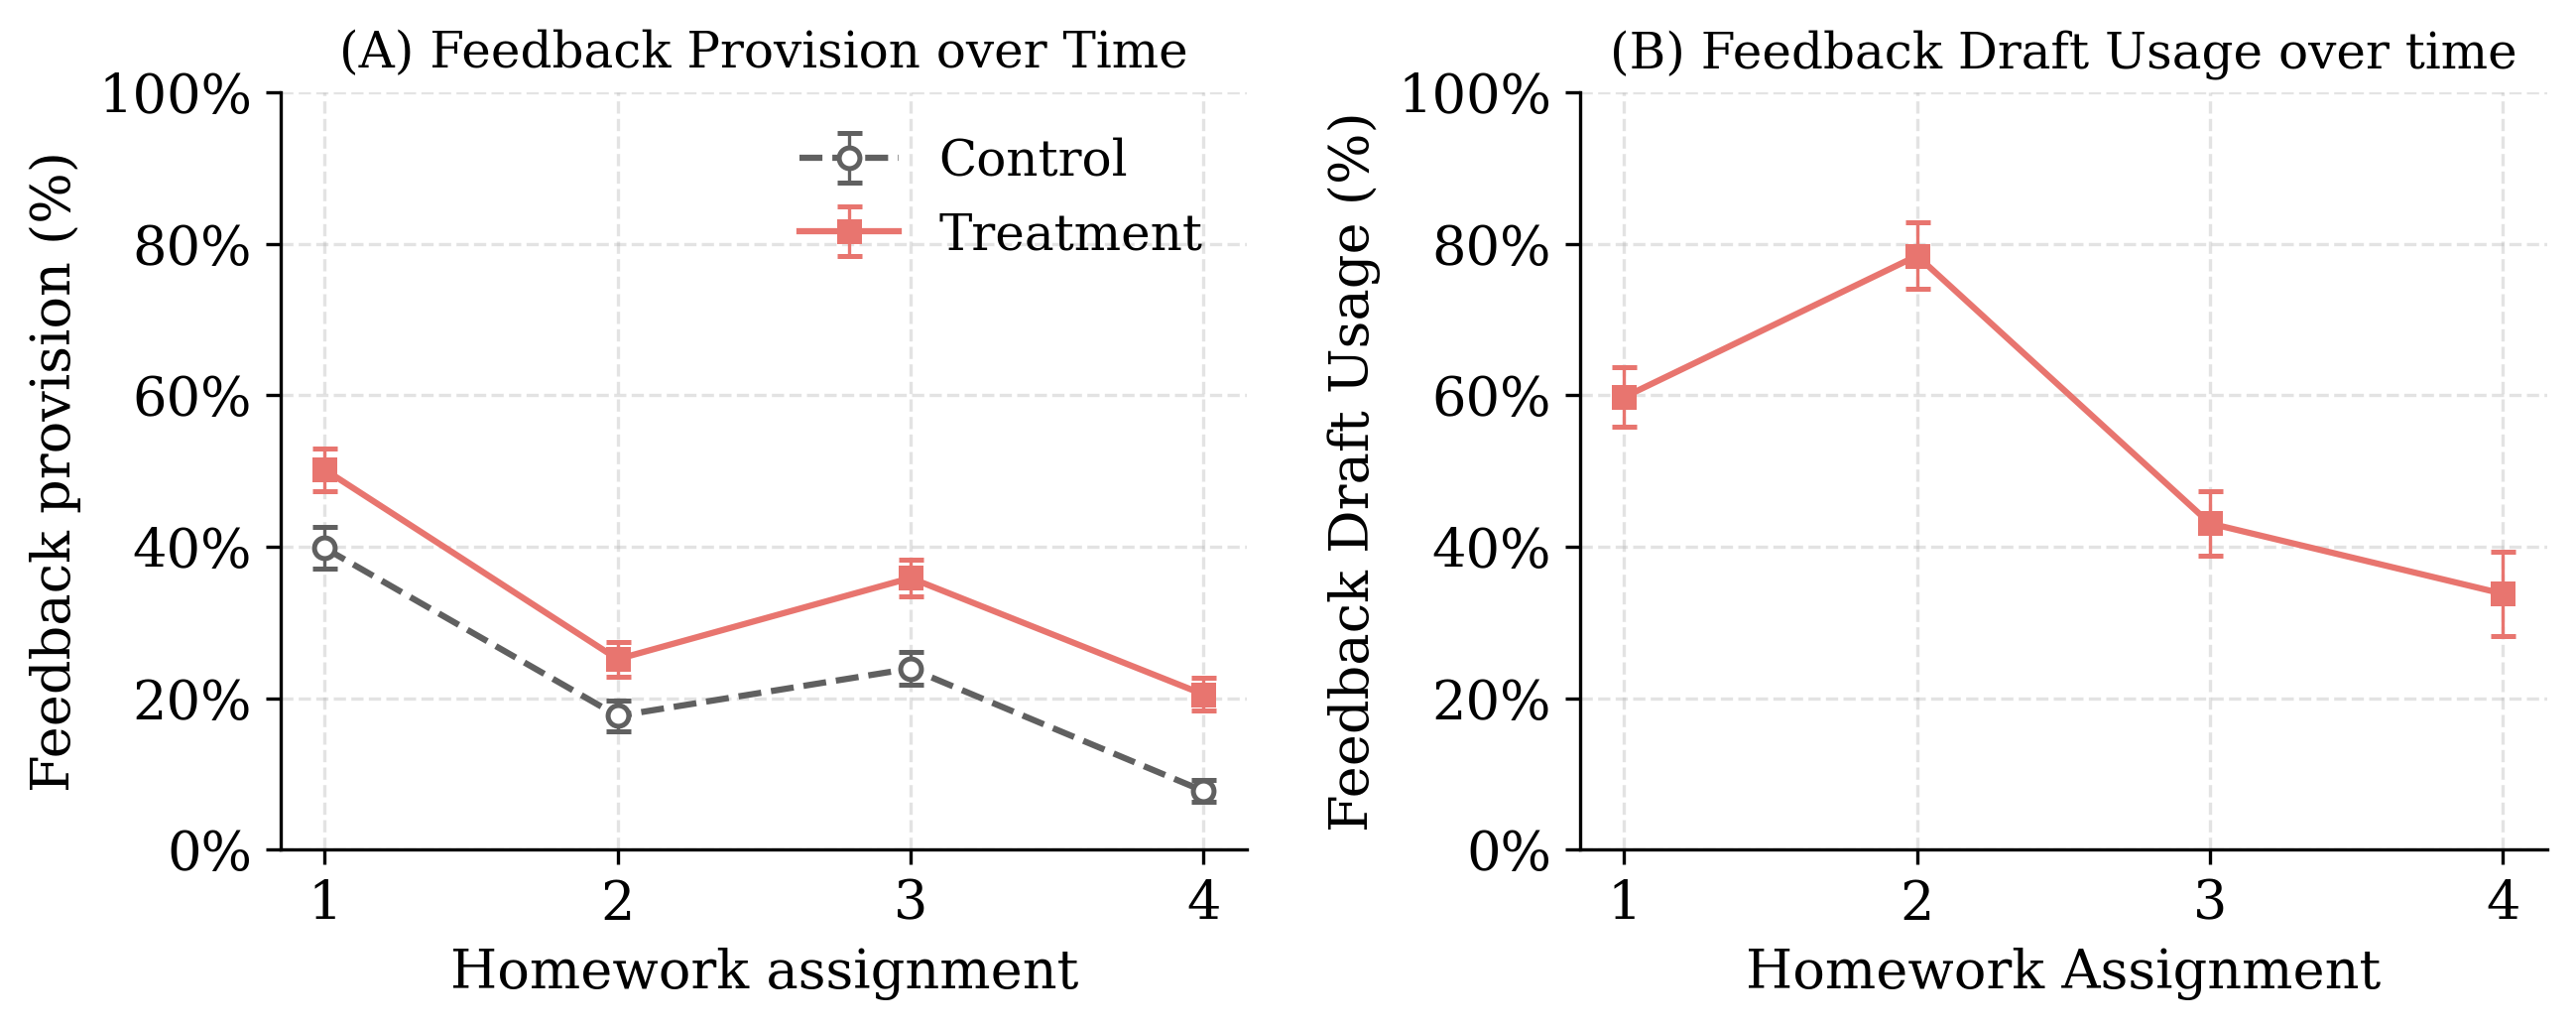

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ----------------------------
# Style configuration
# ----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13,           
    "axes.titlesize": 12,
    "axes.titleweight": "normal",
    "axes.labelsize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
    "lines.linewidth": 1.5,
    "lines.markersize": 5,
    "legend.frameon": False,
    "legend.fontsize": 12,
    "figure.dpi": 300,
})

STYLES = {
    "Control":   {"color": "#606060", "linestyle": "--", "marker": "o", "mfc": "white"},
    "Treatment": {"color": "#E8756F", "linestyle": "-",  "marker": "s", "mfc": "#E8756F"},
}

# ----------------------------
# Prepare data
# ----------------------------
provision = shared_hw[shared_hw["outcome"] == "feedback_provision"].copy()
provision["mean_pct"] = provision["mean"] * 100
provision["se_pct"]   = provision["se"]   * 100

usage = treatment_hw[treatment_hw["outcome"] == "draft_usage"].copy()
usage["mean_pct"] = usage["mean"] * 100
usage["se_pct"]   = usage["se"]   * 100

# ----------------------------
# Plot
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharex=False)

# --- Panel A: feedback provision ---
for treatment_value, label in [(0, "Control"), (1, "Treatment")]:
    subset = provision[provision["treatment"] == treatment_value].sort_values("hw_id")
    s = STYLES[label]
    axes[0].errorbar(
        subset["hw_id"], subset["mean_pct"], yerr=subset["se_pct"],
        marker=s["marker"], linestyle=s["linestyle"], capsize=3, label=label,
        color=s["color"], ecolor=s["color"], elinewidth=0.8,
        markeredgecolor=s["color"], markerfacecolor=s["mfc"],
        markeredgewidth=1.2,
    )

axes[0].set_xlabel("Homework assignment")
axes[0].set_ylabel("Feedback provision (%)")
axes[0].set_title("(A) Feedback Provision over Time", loc="center")
axes[0].set_ylim(0, 100)
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter("%g%%"))
axes[0].set_xticks(provision["hw_id"].unique())
axes[0].legend(loc="upper right")

# --- Panel B: draft usage (treatment-only, use Treatment color) ---
usage_sorted = usage.sort_values("hw_id")
axes[1].errorbar(
    usage_sorted["hw_id"], usage_sorted["mean_pct"], yerr=usage_sorted["se_pct"],
    marker="s", linestyle="-", capsize=3,
    color="#E8756F", ecolor="#E8756F", elinewidth=0.8,
    markeredgecolor="#E8756F", markerfacecolor="#E8756F",
    markeredgewidth=1.2,
)

axes[1].set_xlabel("Homework Assignment")
axes[1].set_ylabel("Feedback Draft Usage (%)")
axes[1].set_title("(B) Feedback Draft Usage over time", loc="center")
axes[1].set_ylim(0, 100)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter("%g%%"))
axes[1].set_xticks(usage_sorted["hw_id"].unique())

plt.tight_layout(pad=1.5)
plt.savefig("figures/temporal_trends.pdf", bbox_inches="tight")
plt.show()